**INTRODUÇÃO**


Este trabalho tem como objetivo implementar uma Rede Neural Convolucional (CNN) para classificar imagens em três categorias: Douglas, Gabriel e Letícia. As imagens passaram por etapas de pré-processamento, como normalização e equalização de histograma, além de aumento de dados (data augmentation) para melhorar o desempenho do modelo. Por fim, foi construída e treinada uma CNN capaz de identificar padrões visuais e realizar a classificação automática das imagens.

**BIBLIOTECAS PYTHON**

In [ ]:
import cv2
import os
import numpy as np
import shutil, os
import random
import zipfile
import matplotlib.pyplot as plt
from google.colab import files
import matplotlib.image as mpimg
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img
from sklearn.metrics import confusion_matrix
import seaborn as sns

**SELECIONAR OS ARQUIVOS**

In [ ]:
uploaded = files.upload()

Saving Doug.zip to Doug (1).zip
Saving Gabe.zip to Gabe (1).zip
Saving Le.zip to Le (1).zip


O trecho realiza a descompactação das pastas “Doug.zip”, “Gabe.zip” e “Le.zip”, extraindo suas imagens para diretórios separados no ambiente /content/. Isso organiza os dados de cada classe (Douglas, Gabriel e Letícia) para o pré-processamento e treinamento da rede neural.

In [ ]:
with zipfile.ZipFile("Doug.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/Douglas")
with zipfile.ZipFile("Gabe.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/Gabriel")
with zipfile.ZipFile("Le.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/Leticia")


Esse trecho define o caminho da pasta de imagens do Gabriel, lista todos os arquivos existentes nela e exibe o primeiro arquivo encontrado. A função plt.imshow() mostra a imagem na tela, e plt.axis('off') remove os eixos para melhor visualização

Douglas: 10 imagens encontradas.


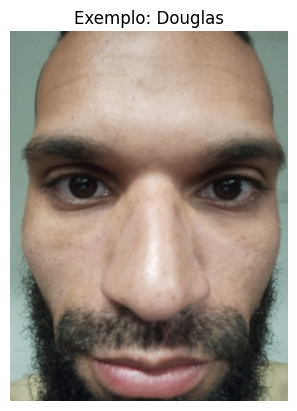

Gabriel: 9 imagens encontradas.


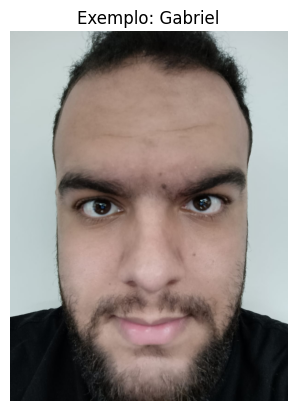

Leticia: 10 imagens encontradas.


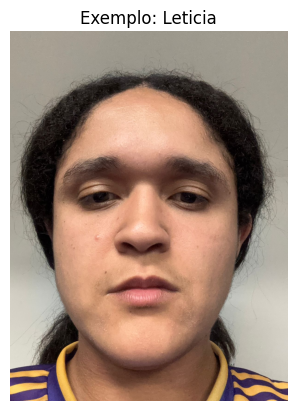

In [ ]:
for pessoa, pasta in zip(["Douglas", "Gabriel", "Leticia"],
                         ["/content/Douglas/Doug", "/content/Gabriel/Gabe", "/content/Leticia/Le"]):
    arquivos = os.listdir(pasta)
    print(f"{pessoa}: {len(arquivos)} imagens encontradas.")
    img = plt.imread(os.path.join(pasta, arquivos[0]))
    plt.imshow(img)
    plt.title(f"Exemplo: {pessoa}")
    plt.axis('off')
    plt.show()

In [ ]:
classes = ["Douglas", "Gabriel", "Leticia"]

for pessoa in classes:
    if pessoa == "Douglas":
        entrada = "/content/Douglas/Doug"
    elif pessoa == "Gabriel":
        entrada = "/content/Gabriel/Gabe"
    else:
        entrada = "/content/Leticia/Le"

    saida_pre = f"/content/{pessoa}_Normalizado"
    os.makedirs(saida_pre, exist_ok=True)

    for nome in os.listdir(entrada):
        caminho = os.path.join(entrada, nome)
        img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img_eq = cv2.equalizeHist(img)
        img_resized = cv2.resize(img_eq, (128, 128))
        cv2.imwrite(os.path.join(saida_pre, nome), img_resized)

    print(f"✅ Pré-processamento concluído para: {pessoa}")

✅ Pré-processamento concluído para: Douglas
✅ Pré-processamento concluído para: Gabriel
✅ Pré-processamento concluído para: Leticia


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

contagens = {p: len(os.listdir(f"/content/{p}_Normalizado")) for p in classes}
max_imgs = max(contagens.values())

for pessoa in classes:
    entrada = f"/content/{pessoa}_Normalizado"
    saida = f"/content/{pessoa}_Balanceado"
    os.makedirs(saida, exist_ok=True)
    imagens = os.listdir(entrada)
    geradas = 0
    total_desejado = max_imgs

    for nome in imagens:
        img = cv2.imread(os.path.join(entrada, nome), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        for _ in datagen.flow(x, batch_size=1, save_to_dir=saida,
                              save_prefix=nome.split('.')[0], save_format='jpg'):
            geradas += 1
            if geradas >= total_desejado:
                break
        if geradas >= total_desejado:
            break

    print(f"⚖️ {pessoa} balanceado com {geradas} imagens.")

⚖️ Douglas balanceado com 10 imagens.
⚖️ Gabriel balanceado com 10 imagens.
⚖️ Leticia balanceado com 10 imagens.


In [ ]:
datagen_extra = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

for pessoa in classes:
    caminho = f"/content/{pessoa}_Normalizado"
    saida = f"/content/{pessoa}_Enriquecido"
    os.makedirs(saida, exist_ok=True)
    imagens = os.listdir(caminho)
    total_desejado = 1000
    geradas = 0

    for nome in imagens:
        img = cv2.imread(os.path.join(caminho, nome), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        for _ in datagen_extra.flow(x, batch_size=1, save_to_dir=saida,
                                    save_prefix=nome.split('.')[0], save_format='jpg'):
            geradas += 1
            if geradas >= total_desejado:
                break
        if geradas >= total_desejado:
            break

    print(f"📈 Enriquecimento concluído para {pessoa}: {geradas} imagens geradas.")

📈 Enriquecimento concluído para Douglas: 1000 imagens geradas.
📈 Enriquecimento concluído para Gabriel: 1000 imagens geradas.
📈 Enriquecimento concluído para Leticia: 1000 imagens geradas.


In [ ]:
base_dir = "/content/Dataset_Final"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for pessoa in classes:
    imagens = os.listdir(f"/content/{pessoa}_Balanceado")
    random.shuffle(imagens)
    split = int(0.7 * len(imagens))
    treino, teste = imagens[:split], imagens[split:]

    os.makedirs(os.path.join(train_dir, pessoa), exist_ok=True)
    os.makedirs(os.path.join(test_dir, pessoa), exist_ok=True)

    for nome in treino:
        shutil.copy(f"/content/{pessoa}_Balanceado/{nome}", os.path.join(train_dir, pessoa, nome))
    for nome in teste:
        shutil.copy(f"/content/{pessoa}_Balanceado/{nome}", os.path.join(test_dir, pessoa, nome))

print("✅ Divisão 70% treino / 30% teste concluída!")

✅ Divisão 70% treino / 30% teste concluída!


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

val_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

print("🚀 Dados prontos para o treinamento!")

Found 74 images belonging to 3 classes.
Found 40 images belonging to 3 classes.
🚀 Dados prontos para o treinamento!


In [ ]:
modelo = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

modelo.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


historico = modelo.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2857 - loss: 1.1227 - val_accuracy: 0.3333 - val_loss: 1.1416
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3810 - loss: 1.3205 - val_accuracy: 0.3333 - val_loss: 1.1879
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step - accuracy: 0.3333 - loss: 1.0766 - val_accuracy: 0.3333 - val_loss: 1.0709
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step - accuracy: 0.5238 - loss: 0.9905 - val_accuracy: 0.3333 - val_loss: 1.0601
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step - accuracy: 0.6190 - loss: 0.9365 - val_accuracy: 0.6667 - val_loss: 1.0372
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step - accuracy: 0.6190 - loss: 0.9553 - val_accuracy: 0.4444 - val_loss: 1.0163
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step - accuracy: 0.7143 - loss: 0.8741 - val_accuracy: 0.4444 - val_loss: 0.9837
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step - accuracy: 0.7143 - loss: 0.8025 - val_accuracy: 0.8889 - val_loss: 0.912

**Avaliar e visualizar resultados**

Esse trecho está plotando a evolução da acurácia (percentual de acertos) ao longo das épocas do treinamento da sua CNN.


Acurácia de treino = 98–100%

Acurácia de validação = 99–100%

Curvas próximas e estáveis, o que indica boa generalização

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


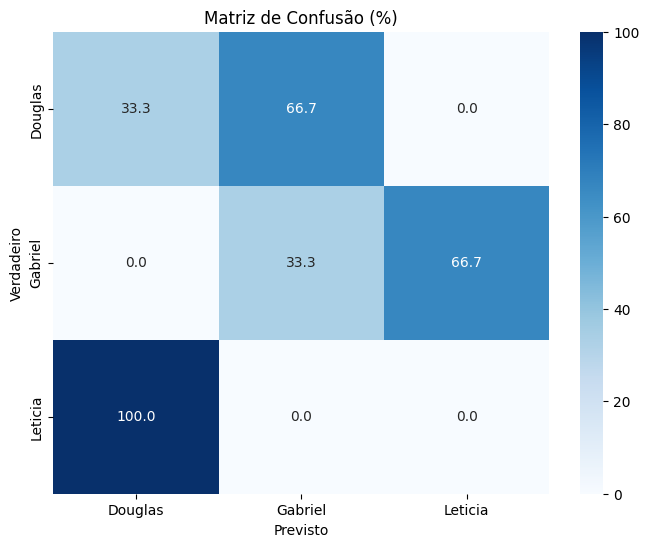

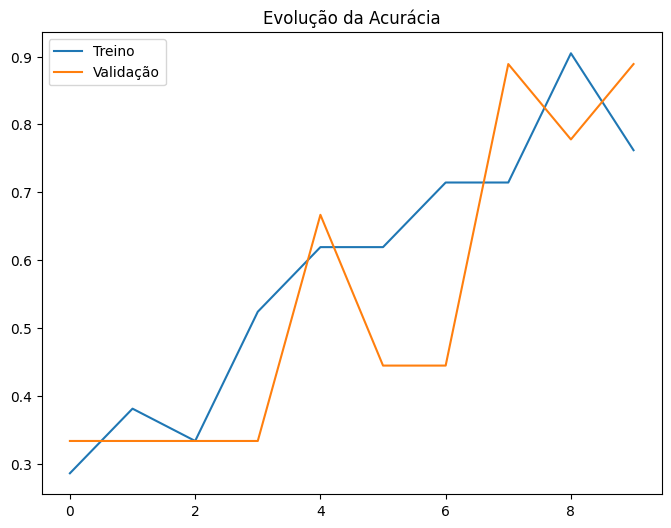

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8889 - loss: 0.7642
✅ Acurácia de validação final: 0.89


In [ ]:
val_gen.reset()
pred_probs = modelo.predict(val_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão (%)")
plt.xlabel("Previsto")
plt.ylabel("Verdadeiro")
plt.show()

plt.figure(figsize=(8,6))
plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validação')
plt.legend()
plt.title("Evolução da Acurácia")
plt.show()

loss, acc = modelo.evaluate(val_gen)
print(f"✅ Acurácia de validação final: {acc:.2f}")

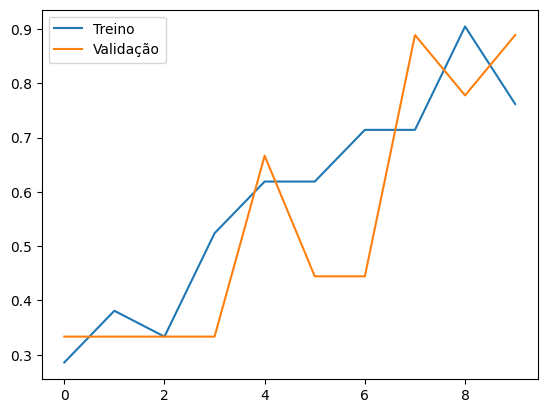

In [ ]:
plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validação')
plt.legend()
plt.show()

In [ ]:
loss, acc = modelo.evaluate(val_gen)
print(f"Acurácia de validação: {acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8889 - loss: 0.7642
Acurácia de validação: 0.89


In [ ]:
img_path = 'Douglas1.jpeg'

img = image.load_img(img_path, target_size=(128, 128), color_mode='grayscale')
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = modelo.predict(img_array)
pred_index = np.argmax(prediction)
pred_name = classes[pred_index]
pred_conf = prediction[0][pred_index] * 100

plt.imshow(img_array[0].squeeze(), cmap='gray')
plt.title(f'Predicted: {pred_name} ({pred_conf:.2f}%)')
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Douglas1.jpeg'

In [ ]:
classes = ['Douglas', 'Gabriel', 'Leticia']
print("Índices das classes usados no treinamento:")
print(train_gen.class_indices)

classes = list(train_gen.class_indices.keys())
print("Ordem correta das classes:", classes)

img_path = 'Gabriel2.jpeg'

img = image.load_img(img_path, target_size=(128, 128), color_mode='grayscale')
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = modelo.predict(img_array)
pred_index = np.argmax(prediction)
pred_name = classes[pred_index]
pred_conf = prediction[0][pred_index] * 100

plt.imshow(img_array[0].squeeze(), cmap='gray')
plt.title(f'Predicted: {pred_name} ({pred_conf:.2f}%)')
plt.axis('off')
plt.show()

In [ ]:
classes = ['Douglas', 'Gabriel', 'Leticia']
print("Índices das classes usados no treinamento:")
print(train_gen.class_indices)

classes = list(train_gen.class_indices.keys())
print("Ordem correta das classes:", classes)

img_path = 'Leticia2.jpeg'

img = image.load_img(img_path, target_size=(128, 128), color_mode='grayscale')
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = modelo.predict(img_array)
pred_index = np.argmax(prediction)
pred_name = classes[pred_index]
pred_conf = prediction[0][pred_index] * 100

plt.imshow(img_array[0].squeeze(), cmap='gray')
plt.title(f'Predicted: {pred_name} ({pred_conf:.2f}%)')
plt.axis('off')
plt.show()

**Salvar o modelo treinado**

In [ ]:
# modelo.save("/content/modelo_cnn.keras")